# TriCheck-LK - Multilingual Dataset Exploration

This notebook explores the extracted Sri Lankan government circular dataset
before multilingual text preprocessing and semantic consistency analysis.

## Dataset
- 100 government circulars
- 3 languages: English, Sinhala and Tamil
- 300 extracted documents

## Extraction Methods
- Direct PDF text extraction using PyMuPDF
- OCR fallback using Tesseract for scanned or low-text PDFs

In [12]:
import pandas as pd

In [13]:
path=   "C:/Users/User/Desktop/TriCheck_LK/data/processed/extracted_documents_clean.jsonl"


In [14]:
df = pd.read_json(path,lines=True)

print("Dataset shape:", df.shape)

Dataset shape: (4656, 8)


In [15]:
df.head()

,circular_id,circular_number,year,language,pdf_url,extraction_status,character_count,text
0,2221,17/2026,2026,English,https://pubad.gov.lk/web/images/circulars/2026...,DIRECT_TEXT,23362,Public Administration Circular : 17/2026 \n \n...
1,2221,17/2026,2026,Sinhala,https://pubad.gov.lk/web/images/circulars/2026...,DIRECT_TEXT,22167,රාජ්‍ය පරිපාලන චක්‍රලේඛ 17/2026 \nමලේේ අංකය...
2,2221,17/2026,2026,Tamil,https://pubad.gov.lk/web/images/circulars/2026...,DIRECT_TEXT,26276,அரசாங்க நிர்வாகச் சுற்றறிக்கக : 17/2026 \n \n...
3,2220,12/2003 (V),2026,English,https://pubad.gov.lk/web/images/circulars/2026...,DIRECT_TEXT,2507,Public Administration Circular : 12/2003(V) \n...
4,2220,12/2003 (V),2026,Sinhala,https://pubad.gov.lk/web/images/circulars/2026...,DIRECT_TEXT,2632,රාජ්‍ය පරිපරාන පක්‍ර\nලේඛ ප: 12/2003(V) \nමල...


In [17]:
df["language"].value_counts()

language
English    1552
Sinhala    1552
Tamil      1552
Name: count, dtype: int64

In [16]:
print("Columns:")
print(df.columns.tolist())

Columns:
['circular_id', 'circular_number', 'year', 'language', 'pdf_url', 'extraction_status', 'character_count', 'text']


In [18]:
# Check missing values in each column
df.isnull().sum()

circular_id          0
circular_number      0
year                 0
language             0
pdf_url              0
extraction_status    0
character_count      0
text                 0
dtype: int64

In [19]:
df["extraction_status"].value_counts()

extraction_status
DIRECT_TEXT    3541
OCR_TEXT       1115
Name: count, dtype: int64

In [20]:
#document length statistics
df.groupby("language")["character_count"].describe()

,count,mean,std,min,25%,50%,75%,max
language,,,,,,,,
English,1552.0,7236.382088,28205.491485,544.0,1283.0,1978.0,4806.75,569729.0
Sinhala,1552.0,7311.085052,28491.058608,506.0,1220.0,1858.5,4419.00,567643.0
Tamil,1552.0,7683.014820,29138.257226,504.0,1377.0,2105.0,4898.75,609785.0


In [21]:
language_per_circular = (
    df.groupby("circular_id")["language"]
    .nunique()
)

print(
    "Total circulars:",
    language_per_circular.shape[0]
)

print(
    "Circulars with exactly 3 languages:",
    (language_per_circular == 3).sum()
)

print(
    "Incomplete circulars:",
    (language_per_circular != 3).sum()
)

Total circulars: 1552
Circulars with exactly 3 languages: 1552
Incomplete circulars: 0


OCR usage by language

In [22]:
# Extraction method by language
extraction_by_language = pd.crosstab(
    df["language"],
    df["extraction_status"]
)

extraction_by_language

extraction_status,DIRECT_TEXT,OCR_TEXT
language,,
English,1295,257
Sinhala,1258,294
Tamil,988,564


Document length visualization

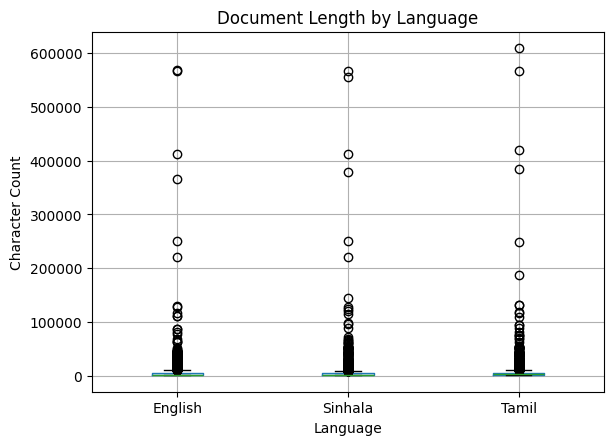

In [23]:
import matplotlib.pyplot as plt

df.boxplot(
    column="character_count",
    by="language"
)

plt.title("Document Length by Language")
plt.suptitle("")
plt.xlabel("Language")
plt.ylabel("Character Count")
plt.show()


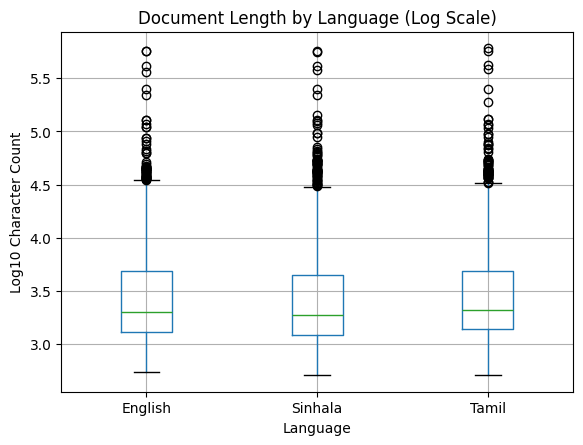

In [24]:
df["log_character_count"] = (
    df["character_count"] + 1
).apply(lambda x: __import__("math").log10(x))

df.boxplot(
    column="log_character_count",
    by="language"
)

plt.title("Document Length by Language (Log Scale)")
plt.suptitle("")
plt.xlabel("Language")
plt.ylabel("Log10 Character Count")
plt.show()